---
format:
  html:
    code-fold: show
---

## 2D-plots

Matplotlib is a data visualization library for creating static, animated and interactive figures. Pyplot is the interface that we use to conveniently access the library.

Import the Matplotlib module `pyplot` only once at the beginning of your code. It is commonly imported as `plt` to reduce the amount of typing.

In [36]:
import matplotlib.pyplot as plt

We begin by defining two new symbolic variables `alpha` and `beta` that will be used to define two new symbolic expressions `V_x` and `V_y`. The symbolic expressions are first converted into numerical functions using `lambdify()`.

In [37]:
alpha, beta = sp.symbols('alpha, beta', real=True)
V_x = 10 * sp.cos(alpha)
V_y = beta * sp.sin(alpha)

V_x_np = sp.lambdify([alpha, beta], V_x)
V_y_np = sp.lambdify([alpha, beta], V_y)

A very common thing we want to do is to plot how some function varies when we change its variables within some range. The following code is a minimal example of that.

It is good practice to separate "figure settings" from the actual drawing/plotting. Use comments `#` to separate code into individual sections in the same cell. We begin by setting the color-theme to `seaborn-v0_8-whitegrid` because it looks a bit nicer than the default. We initialize a new *figure object* `fig` with a specific size: 7.25 x 7.25 (inches). Then we add a new *axis object* `ax` to `fig` using the function add_subplot(). This is necessary to access some of the settings that we want to make, and it also enables us to plot multiple things in the same figure if we need to. The axis limits `xlim` and `ylim` are set manually, but can also be left out which will set them dynamically. The labels `xlabel` and `ylabel` are set to indicate what is shown on each axis. Do not forget to specify the units. Some parameters controlling the appearance of the background grid are modified using `plt.grid()` and `plt.minorticks_on()`. 

The actual data visualization happens with the two plt.plot() commands. 

Note the creation of `alphas` using `linspace()` which contains $100$ numbers between $0$ and $2\pi$.

It is good/best practice to always switch to degrees when you visualize, but always use radians when performing the actual calculations. Note how the first component of plt.plot() is simply multiplied by `180/np.pi` to achieve this.

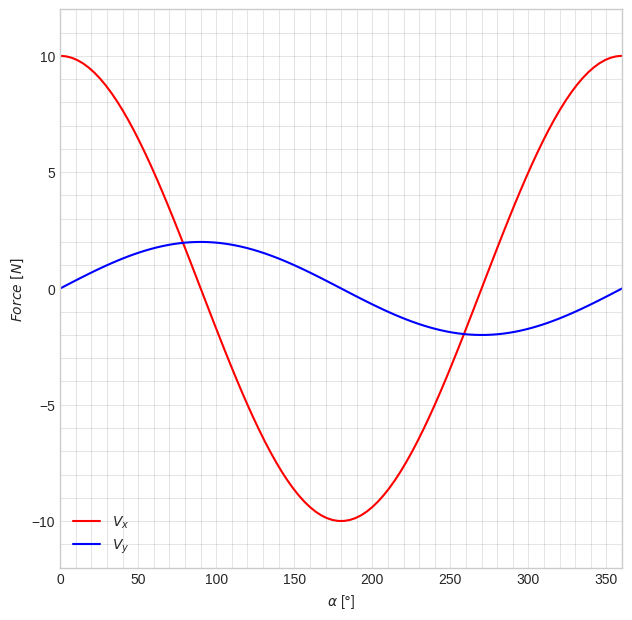

In [38]:
# 2D figure settings
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(7.25, 7.25))
ax = fig.add_subplot()
ax.set(xlim=[0.0, 360.0], ylim=[-12.0, 12.0], 
       xlabel=r'$\alpha$ [$\degree$]', ylabel=r'$Force~[N]$')
plt.grid(True, which='both', color='k', linestyle='-', alpha=0.1)
plt.minorticks_on()

# draw V_x and V_y for all alphas, with fixed beta=1 and beta=2
alphas = np.linspace(0, 2*np.pi, 100)
plt.plot(alphas*180/np.pi, V_x_np(alphas, 1), color='red', label=r'$V_x$')
plt.plot(alphas*180/np.pi, V_y_np(alphas, 2), color='blue', label=r'$V_y$')

# draw legend
plt.legend()

### 2D vector plots

We begin by defining some new numerical vectors that can be used for the following examples. They can easily be replaced by your own symbolic vectors using the methodology described in the `SymPy` and `NumPy` sections above:

In [39]:
theta = np.pi/3 # slider variable here for example!
rr_OA = 0.5 * np.array([np.cos(theta), np.sin(theta), 0])
rr_OB = 0.9 * np.array([np.sin(theta), np.cos(theta), 0])
rr_O = np.array([0, 0, 0])

To verify that you have defined all positional vectors correctly, we typically want to visualize them. The following is a minimal 2D example of that. 

The figure settings are the same as in the initial 2D data plot, with the addition of `set_aspect()` which forces the figure to have the same width as height.
Drawing of vectors is done using `quiver()` and some points and text-labels are added using `plot()` and `text()`. Finally, a legend is added to the plot.
Note the "slicing" of vectors in quiver(), for example: `rr_O[:-1]` where [:-1] means that the last entry (the z-component) of the initial 3D-vector is removed.

Note also that we have to set the `scale`-property of our `quiver()` for each set of `xlim` and `ylim` by trial-and-error.
Note also the small adjustments to the position in the `text()` entries which prevents the text from being positioned exactly at each point.
The `zorder` parameter sets the "layer" of the points, so that they are drawn on top of everything with a lower value than 10.

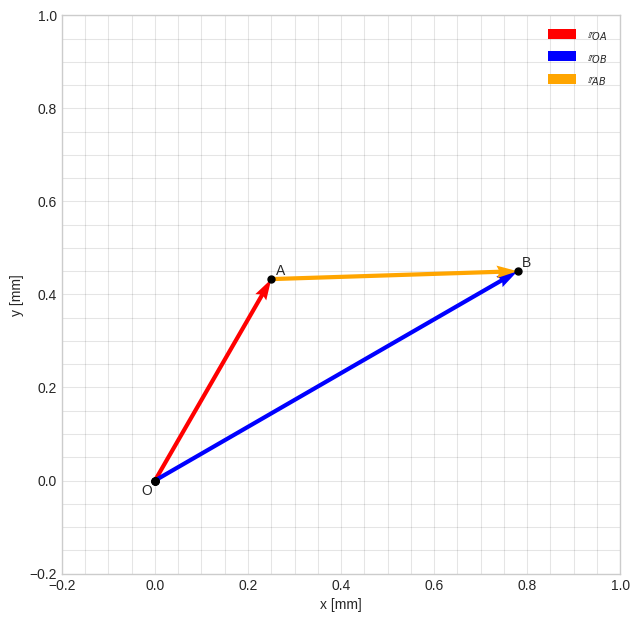

In [40]:
# 2D figure settings
plt.style.use('seaborn-v0_8-whitegrid')
fig2 = plt.figure(figsize=(7.25, 7.25))
ax2 = fig2.add_subplot()
ax2.set_aspect('equal')
ax2.set(xlim=[-0.2, 1.0], ylim=[-0.2, 1.0], xlabel='x [mm]', ylabel='y [mm]')
plt.grid(True, which='both', color='k', linestyle='-', alpha=0.1)
plt.minorticks_on()

# draw quivers
ax2.quiver(*rr_O[:-1], *rr_OA[:-1], 
           color='red', scale=1.2, label='$\\mathbb{r}_{OA}$')
ax2.quiver(*rr_O[:-1], *rr_OB[:-1], 
           color='blue', scale=1.2, label='$\\mathbb{r}_{OB}$')
ax2.quiver(*rr_OA[:-1], *(rr_OB[:-1]-rr_OA[:-1]),
           color='orange', scale=1.2, label='$\\mathbb{r}_{AB}$')

# if you dislike quiver(), you can draw lines using plot() and zip() instead
# ax2.plot(*zip(rr_O[:-1], rr_OA[:-1]), 
#          color='red', linewidth=2.5, label='$\\mathbb{r}_{OA}$')
# ax2.plot(*zip(rr_O[:-1], rr_OB[:-1]), 
#          color='blue', linewidth=2.5, label='$\\mathbb{r}_{OB}$')
# ax2.plot(*zip(rr_OB[:-1], rr_OA[:-1]), 
#          color='orange', linewidth=2.5, label='$\\mathbb{r}_{AB}$')

# draw points
ax2.plot(*rr_O, marker='o', color='black', markersize=5, zorder=10)
ax2.plot(*rr_OA, marker='o', color='black', markersize=5, zorder=10)
ax2.plot(*rr_OB, marker='o', color='black', markersize=5, zorder=10)

# draw point labels
ax2.text(*rr_O[:-1]-0.03, 'O') # - small adjustment
ax2.text(*rr_OA[:-1]+0.01, 'A') # + small adjustment
ax2.text(*rr_OB[:-1]+0.01, 'B') # + small adjustment

# draw legend
ax2.legend()
